## Treinando o Modelo

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

### Importando o dataset

In [19]:
PATH = '../data/processed/churn-processed.csv'
df = pd.read_csv(PATH)
df.head()

,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_France,country_Germany,country_Spain,has_balance,dead_client,age_group,product_group
0,619,1,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0,0,0,2,0
1,608,1,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0,1,0,2,0
2,502,1,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0,1,0,2,1
3,699,1,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0,0,1,2,0
4,850,1,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0,1,0,2,0


### Aqui farei o split treino-teste e o treino do modelo

In [20]:
features = df.drop('churn', axis=1)
target = df['churn']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## Resultados
### Classification report

In [22]:
print(classification_report(y_test, y_pred.round()))

              precision    recall  f1-score   support

           0       0.84      0.98      0.91      1607
           1       0.75      0.26      0.39       393

    accuracy                           0.84      2000
   macro avg       0.80      0.62      0.65      2000
weighted avg       0.83      0.84      0.81      2000



#### Aqui podemos ver que nosso modelo pegou 26% dos clientes que realmente churnaram. 
#### Com uma precisao de 75%

### ROC-AUC Score
#### Nosso modelo conseguiu separar churn de nao-churn 84% das vezes

In [23]:
print("ROC AUC Score:", roc_auc_score(y_test, y_pred))

ROC AUC Score: 0.8419763407864131


### Confusion Matrix

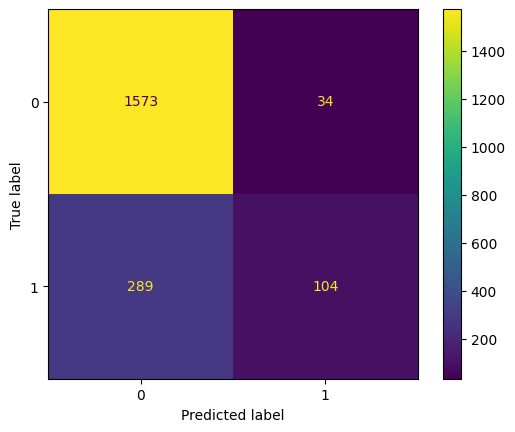

In [24]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred.round())
plt.show()

### Conclusao
#### O modelo performa bem em idenficicar nao-churn, mas na deteccao de chrun esta bem abaixo, resultando em um baixo recall
#### Isso indica que o modelo esta enviesado para a classe majoritaria

## Melhorando o modelo

#### Num primeiro momento irei ajustar o treshold do modelo

In [32]:


X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=50000)
model.fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

/home/hennis/miniconda3/envs/ds/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 13140 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [36]:
from sklearn.metrics import recall_score, precision_score, f1_score

for threshold in [0.5, 0.4, 0.3, 0.2, 0.1]:
    y_pred = (y_prob >= threshold).astype(int)

    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Threshold: {threshold}")
    print(f"Recall: {recall}")
    print(f"Precision: {precision}")
    print(f"F1: {f1}")
    print("\n")

Threshold: 0.5
Recall: 0.3791348600508906
Precision: 0.7233009708737864
F1: 0.4974958263772955


Threshold: 0.4
Recall: 0.5318066157760815
Precision: 0.6314199395770392
F1: 0.5773480662983426


Threshold: 0.3
Recall: 0.6437659033078881
Precision: 0.5429184549356223
F1: 0.5890570430733411


Threshold: 0.2
Recall: 0.7913486005089059
Precision: 0.4283746556473829
F1: 0.5558534405719392


Threshold: 0.1
Recall: 0.905852417302799
Precision: 0.31393298059964725
F1: 0.46627373935821875




### Temos duas opcoes viaveis, depois de aplicada o treshold. 
- Opcao 1: treshold = 0.3
- - Mais equilibrada com F1 melhor, um modelo mais seguro
- Opcao 2: treshold = 0.2
- - recall muito alto, perde poucos churns mas em contrapartida tem muito mais falso positivo

### A opcao 1 foi selecionada pois apresenta o melhor balanco recall-precision, maximizando o F1-score.
### Entretanto, se o negocio prioriza minimizar a perda de clientes, um treshold menor  (0.2) pode ser usado para aumentar ainda mais o recall com o custo de mais falsos positivos

## Vamos comparar o modelo base com o modelo de Logistc Regression usando class_weith  e com Random Forest

#### Primeiro modelo é o Baseline (treshold = 0.3)

In [37]:
y_pred = (y_prob >= 0.3).astype(int)

recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Threshold: {threshold}")
print(f"Recall: {recall}")
print(f"Precision: {precision}")
print(f"F1: {f1}")
print("\n")

Threshold: 0.1
Recall: 0.6437659033078881
Precision: 0.5429184549356223
F1: 0.5890570430733411




### Logistic Regression + class_weight

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
model = LogisticRegression(class_weight="balanced", max_iter=50000)
model.fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:, 1]
for threshold in [0.5, 0.4, 0.3, 0.2, 0.1]:
    y_pred = (y_prob >= threshold).astype(int)

    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Threshold: {threshold}")
    print(f"Recall: {recall}")
    print(f"Precision: {precision}")
    print(f"F1: {f1}")
    print("\n")


Threshold: 0.5
Recall: 0.7735368956743003
Precision: 0.4342857142857143
F1: 0.5562671546203111


Threshold: 0.4
Recall: 0.8295165394402035
Precision: 0.376878612716763
F1: 0.5182829888712241


Threshold: 0.3
Recall: 0.8956743002544529
Precision: 0.3262279888785913
F1: 0.4782608695652174


Threshold: 0.2
Recall: 0.9567430025445293
Precision: 0.26330532212885155
F1: 0.41295991213618893


Threshold: 0.1
Recall: 0.9847328244274809
Precision: 0.21976149914821125
F1: 0.3593314763231198


Threshold: 0.1
Recall: 0.7735368956743003
Precision: 0.4342857142857143
F1: 0.5562671546203111




/home/hennis/miniconda3/envs/ds/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 13191 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Random Forest

In [43]:
from sklearn.ensemble import RandomForestClassifier


In [44]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
model = RandomForestClassifier()
model.fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:, 1]
for threshold in [0.5, 0.4, 0.3, 0.2, 0.1]:
    y_pred = (y_prob >= threshold).astype(int)

    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Threshold: {threshold}")
    print(f"Recall: {recall}")
    print(f"Precision: {precision}")
    print(f"F1: {f1}")
    print("\n")


Threshold: 0.5
Recall: 0.48346055979643765
Precision: 0.7364341085271318
F1: 0.5837173579109063


Threshold: 0.4
Recall: 0.5623409669211196
Precision: 0.6424418604651163
F1: 0.5997286295793759


Threshold: 0.3
Recall: 0.6743002544529262
Precision: 0.5475206611570248
F1: 0.6043329532497149


Threshold: 0.2
Recall: 0.8040712468193384
Precision: 0.43646408839779005
F1: 0.5658012533572068


Threshold: 0.1
Recall: 0.9033078880407125
Precision: 0.3271889400921659
F1: 0.4803788903924222




### Analisando os resultados, vemos que o modelo de Logistic Regression com class_weight com treshold de 0.5 seria um bom modelo conservador (recall= 0.77 e precison= 0.43). E caso busquem um modelo mais agressivo, ainda continuar no Logistic Regression + class_weight e treshold de 0.3 (Recall= 0.89 Precision= 0.32)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
model = LogisticRegression(class_weight="balanced", max_iter=50000)
model.fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.75      0.83      1607
           1       0.43      0.77      0.56       393

    accuracy                           0.76      2000
   macro avg       0.68      0.76      0.69      2000
weighted avg       0.83      0.76      0.78      2000



/home/hennis/miniconda3/envs/ds/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 13191 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [57]:
df_final = X_test.copy()
df_final = df_final.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)
df_final["churn_real"] = y_test
df_final["churn_probability"] = y_prob
df_final["churn_predicted"] = y_pred
df_final.head()

,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,country_France,country_Germany,country_Spain,has_balance,dead_client,age_group,product_group,churn_real,churn_probability,churn_predicted
0,596,0,32,3,96709.07,2,0,0,41788.37,0.0,1.0,0.0,1,0,0,0,0,0.154883,0
1,623,0,43,1,0.00,2,1,1,146379.30,1.0,0.0,0.0,0,0,2,0,0,0.129647,0
2,601,1,44,4,0.00,2,1,0,58561.31,0.0,0.0,1.0,0,1,2,0,0,0.421852,0
3,506,0,59,8,119152.10,2,1,1,170679.74,0.0,1.0,0.0,1,0,3,0,0,0.460640,0
4,560,1,27,7,124995.98,1,1,1,114669.79,0.0,0.0,1.0,1,0,0,0,0,0.198664,0


In [59]:
df_final

,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,country_France,country_Germany,country_Spain,has_balance,dead_client,age_group,product_group,churn_real,churn_probability,churn_predicted
0,596,0,32,3,96709.07,2,0,0,41788.37,0.0,1.0,0.0,1,0,0,0,0,0.154883,0
1,623,0,43,1,0.00,2,1,1,146379.30,1.0,0.0,0.0,0,0,2,0,0,0.129647,0
2,601,1,44,4,0.00,2,1,0,58561.31,0.0,0.0,1.0,0,1,2,0,0,0.421852,0
3,506,0,59,8,119152.10,2,1,1,170679.74,0.0,1.0,0.0,1,0,3,0,0,0.460640,0
4,560,1,27,7,124995.98,1,1,1,114669.79,0.0,0.0,1.0,1,0,0,0,0,0.198664,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,602,1,53,5,98268.84,1,0,1,45038.29,0.0,1.0,0.0,1,0,3,0,1,0.851988,1
1996,609,0,25,10,0.00,1,0,1,109895.16,1.0,0.0,0.0,0,0,0,0,0,0.098340,0
1997,730,1,47,7,0.00,1,1,0,33373.26,1.0,0.0,0.0,0,1,3,0,1,0.848968,1
1998,692,0,29,4,0.00,1,1,0,76755.99,1.0,0.0,0.0,0,1,0,0,1,0.246281,0


In [60]:
df_final.to_csv('../data/processed/churn_predictions.csv', index=False)

### Proximo passo sera montar num dashboard em PowerBI